In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# =========================
# NASTAVENÍ
# =========================
SEASONS_ORDER = ["2020-21", "2021-22", "2022-23", "2023-24", "2024-25"]
SEASONS_SET = set(SEASONS_ORDER)
RESULTS_DIR = Path("../results")
RESULTS_ML_DIR = Path("../results_ml/vybrane_featury")
SEASONS_FINAL = [ "2020-21", "2021-22", "2022-23", "2023-24", "2024-25"]
# Sem dej svoje výstupní CSV soubory s úspěšností metod:
# Musí mít sloupce: season, file, round, matches, correct, accuracy
METHOD_FILES = {
    # "název v legendě": "soubor.csv",
    "Dumb (tabulka)": "results_dumb_sazkar.csv",
    "Random uniform": "results_random_uniform.csv",
    "Random empirical": "results_random_empirical.csv",
    "1 year ELO (strict)": "results_country_elo_1season.csv",
    "5 year ELO (strict)": "results_country_elo_5season.csv",
    "Elo (strict)": "elo_week_roundstyle_strict.csv",
    "Elo (threshold)": "elo_week_roundstyle_threshold.csv",
    "Dixon-Coles": "results_dixon_coles_weekly.csv",
}

In [2]:
def load_method_csv(path: Path, method: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    required = {"season", "file", "round", "matches", "correct", "accuracy"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path}: chybí sloupce {missing}")

    df["season"] = df["season"].astype(str).str.strip()
    df = df[df["season"].isin(SEASONS_SET)].copy()

    df["round"] = pd.to_numeric(df["round"], errors="coerce").astype("Int64")
    df["matches"] = pd.to_numeric(df["matches"], errors="coerce")
    df["correct"] = pd.to_numeric(df["correct"], errors="coerce")
    df["accuracy"] = pd.to_numeric(df["accuracy"], errors="coerce")

    df = df.dropna(subset=["round", "matches", "correct", "accuracy"]).copy()
    df["round"] = df["round"].astype(int)

    df["method"] = method
    return df


# načtení všech metod
frames = []
for method, file in METHOD_FILES.items():
    frames.append(load_method_csv(path=RESULTS_DIR / file, method=method))

df = pd.concat(frames, ignore_index=True)
df.head()
# sjednotit sezonu: 2014/15 -> 2014-15, odstranit mezery
df["season"] = (
    df["season"].astype(str)
      .str.strip()
      .str.replace("/", "-", regex=False)
)

# číselný rok začátku sezóny (2014 z "2014-15")
df["start_year"] = pd.to_numeric(df["season"].str[:4], errors="coerce")
df = df.dropna(subset=["start_year"]).copy()
df["start_year"] = df["start_year"].astype(int)

# filtrování období (2014/15 až 2019/20)
df = df[(df["start_year"] >= 2020) & (df["start_year"] <= 2025)].copy()

In [3]:
agg = (
    df.groupby(["method", "season", "start_year", "round"], as_index=False)
      .agg(matches=("matches","sum"), correct=("correct","sum"))
)
agg["accuracy"] = agg["correct"] / agg["matches"]

# správné chronologické řazení
agg = agg.sort_values(["start_year", "round", "method"]).reset_index(drop=True)


In [4]:
# osa X = index podle (start_year, round)
sr = (
    agg[["season", "start_year", "round"]]
      .drop_duplicates()
      .sort_values(["start_year", "round"])
      .reset_index(drop=True)
)
sr["x"] = sr.index
sr["label"] = sr["season"] + " r" + sr["round"].astype(str)

agg = agg.merge(sr, on=["season","start_year","round"], how="left")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


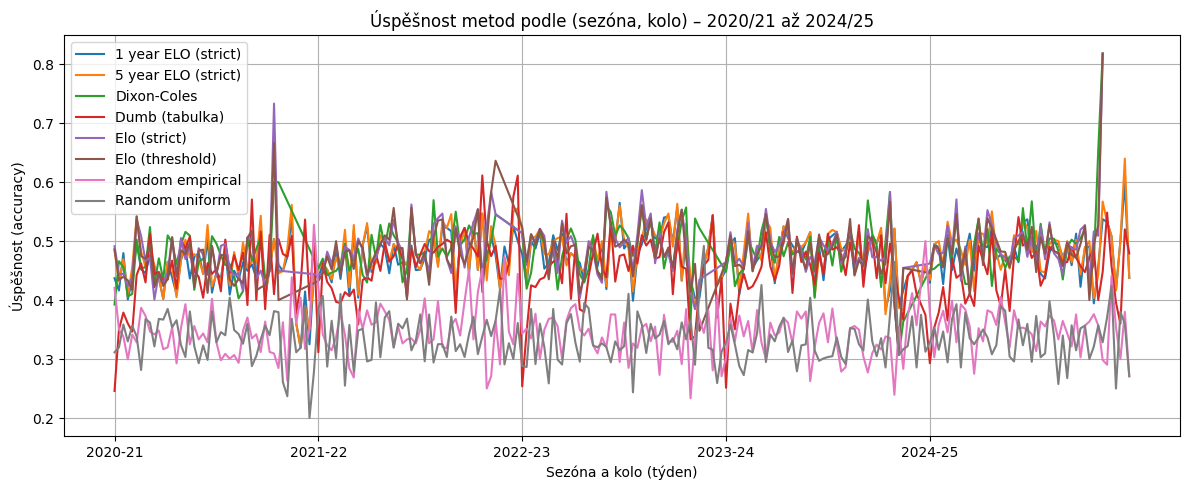

In [5]:
plt.figure(figsize=(12,5))
for method, part in agg.groupby("method", sort=False):
    part = part.sort_values("x")
    plt.plot(part["x"], part["accuracy"], label=method)

# tick jen na začátku sezón (první round v sezóně)
season_starts = sr.groupby("start_year").first().reset_index()

plt.xticks(season_starts["x"], season_starts["season"], rotation=0)

plt.xlabel("Sezóna a kolo (týden)")
plt.ylabel("Úspěšnost (accuracy)")
plt.title("Úspěšnost metod podle (sezóna, kolo) – 2020/21 až 2024/25")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("../results/accuracy_by_week.eps", format="eps")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


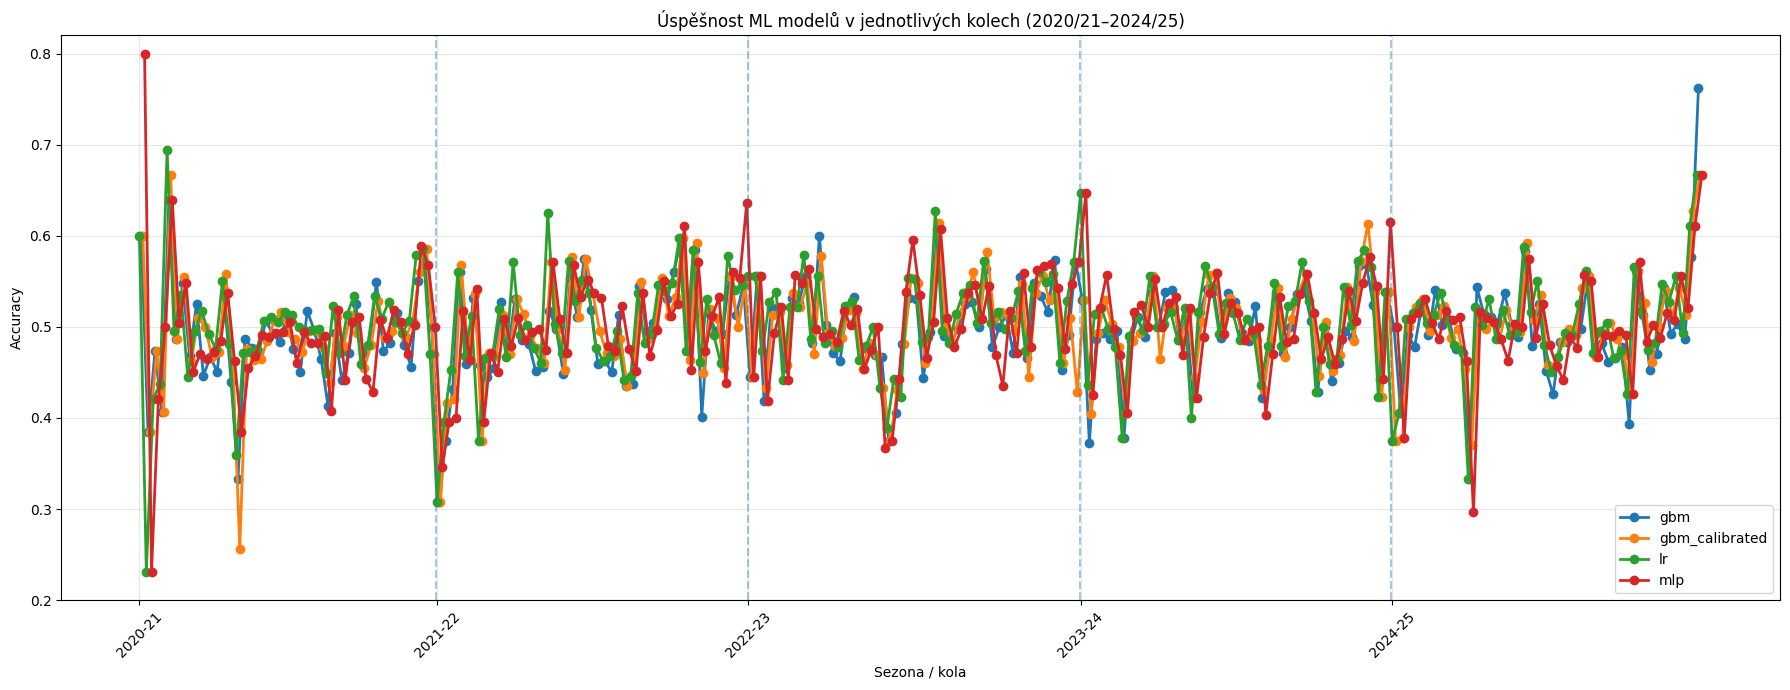

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# cesta k výsledkům ML
ML_PATH = Path("../results_ml/machine_learning_weekly_results.csv")

# sezony které chceme
SEASONS = ["2020-21", "2021-22", "2022-23", "2023-24", "2024-25"]

# načtení
df = pd.read_csv(ML_PATH)

# filtrace
df = df[
    (df["season"].isin(SEASONS)) &
    (df["method"] == "train_4seasons_test_1season_weekly")
].copy()

# pokud se sloupec jmenuje jinak:
# accuracy_col = "test_accuracy"
accuracy_col = "test_accuracy"

# chronologické pořadí sezon
df["season"] = pd.Categorical(df["season"], categories=SEASONS, ordered=True)

# osa x = sezona + kolo
df["x_label"] = df["season"].astype(str) + " R" + df["week"].astype(str)

# seřazení
df = df.sort_values(["season", "week"])

# numerická osa x
df["x"] = range(len(df))

# ===========================
# GRAF
# ===========================
plt.figure(figsize=(18,7))

for model_name, part in df.groupby("model"):
    plt.plot(
        part["x"],
        part[accuracy_col],
        marker="o",
        linewidth=2,
        label=model_name
    )

# oddělovače sezon
for i, season in enumerate(SEASONS[:-1]):
    last_idx = df[df["season"] == season]["x"].max()
    plt.axvline(last_idx + 0.5, linestyle="--", alpha=0.4)

# popisky osy x jen začátky sezon
tick_positions = []
tick_labels = []

for season in SEASONS:
    first_idx = df[df["season"] == season]["x"].min()
    tick_positions.append(first_idx)
    tick_labels.append(season)

plt.xticks(tick_positions, tick_labels, rotation=45)

plt.title("Úspěšnost ML modelů v jednotlivých kolech (2020/21–2024/25)")
plt.xlabel("Sezona / kola")
plt.ylabel("Accuracy")
plt.ylim(0.2,0.82)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("../results_ml/ml_accuracy_rounds_2020_2026.eps", bbox_inches="tight", format="eps")
plt.show()

In [3]:
def logloss_from_probs(df):
    probs = {
        "H": df["Prob_H"].to_numpy(),
        "D": df["Prob_D"].to_numpy(),
        "A": df["Prob_A"].to_numpy(),
    }

    losses = []
    for i, true in enumerate(df["Target"]):
        losses.append(-np.log(max(probs[true][i], 1e-15)))

    return np.mean(losses)


def brier_from_probs(df):
    total = 0

    for _, row in df.iterrows():
        true = row["Target"]

        total += (
            (row["Prob_H"] - (1 if true == "H" else 0)) ** 2 +
            (row["Prob_D"] - (1 if true == "D" else 0)) ** 2 +
            (row["Prob_A"] - (1 if true == "A" else 0)) ** 2
        )

    return total / len(df)


def rps_from_probs(df):
    total = 0

    for _, row in df.iterrows():
        true = row["Target"]

        p = np.array([row["Prob_H"], row["Prob_D"], row["Prob_A"]])
        y = np.array([
            1 if true == "H" else 0,
            1 if true == "D" else 0,
            1 if true == "A" else 0,
        ])

        total += np.sum((np.cumsum(p) - np.cumsum(y)) ** 2) / 2

    return total / len(df)

In [ ]:
results = []

for method, file in METHOD_FILES.items():
    path = RESULTS_DIR / file
    total_correct = 0
    total_matches = 0

    if not path.exists():
        print(f"Chybí soubor: {file}")
        continue

    df = pd.read_csv(path)


    df = df[df["season"].isin([ "2020-21", "2021-22", "2022-23", "2023-24", "2024-25"])]
    df = df[df["file"].isin(["E0","E0_elo.csv"])] 
    total_matches = df["matches"].sum()
    total_correct = df["correct"].sum()

    if total_matches > 0:
        accuracy = total_correct / total_matches
    else:
        accuracy = 0

    # vážené průměry podle počtu zápasů
    if "logloss" in df.columns:
        logloss = (df["logloss"] * df["matches"]).sum() / total_matches
    else:
        logloss = None
    if "brier" in df.columns:
        brier = (df["brier"] * df["matches"]).sum() / total_matches
    else:
        brier = None
    if "rps" in df.columns:
        rps = (df["rps"] * df["matches"]).sum() / total_matches     
    else:
        rps = None

    results.append({
        "method": method,
        "matches": total_matches,
        "correct": total_correct,
        "accuracy": round(accuracy, 4),
        "logloss": round(logloss, 4) if logloss is not None else None,
        "brier": round(brier, 4) if brier is not None else None,
        "rps": round(rps, 4) if rps is not None else None   
    })
# =========================
# MACHINE LEARNING - jen TOP5 lig
# =========================
ml_pred_path = RESULTS_ML_DIR / "machine_learning_match_predictions.csv"

TOP5_LEAGUES = ["E0_elo"]

if ml_pred_path.exists():
    ml_pred = pd.read_csv(
        ml_pred_path,
        usecols=[
            "method", "model", "season", "Div",
            "Target", "Correct",
            "Prob_H", "Prob_D", "Prob_A"
        ],
        engine="python",
        on_bad_lines="skip"
    )

    ml_pred = ml_pred[
        (ml_pred["method"] == "weekly_walk_forward") &
        (ml_pred["season"].isin(SEASONS_FINAL)) &
        (ml_pred["Div"].isin(TOP5_LEAGUES))
    ].copy()

    if not ml_pred.empty:
        for model_name, part in ml_pred.groupby("model"):
            total_matches = len(part)
            total_correct = part["Correct"].sum()

            results.append({
                "method": model_name,
                "matches": total_matches,
                "correct": int(total_correct),
                "accuracy": total_correct / total_matches,
                "logloss": logloss_from_probs(part),
                "brier": brier_from_probs(part),
                "rps": rps_from_probs(part),
            })

else:
    print(f"Chybí ML soubor: {ml_pred_path}")

# =========================
# FINÁLNÍ TABULKA
# =========================
summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values(
    by=["accuracy"],
    ascending=[False],
    na_position="last"
)


summary_df.to_csv("../results/zaverecna_tabulka_metod_featury.csv", index=False)

summary_df  

,method,matches,correct,accuracy,logloss,brier,rps
11,mlp,1900,1030,0.542105,0.984048,0.584259,0.204230
10,lr,1900,1023,0.538421,0.982009,0.583618,0.203971
7,Dixon-Coles,1900,1020,0.536800,0.986600,0.585300,0.204700
9,gbm_calibrated,1900,1018,0.535789,0.989454,0.587713,0.205475
8,gbm,1900,1010,0.531579,1.011795,0.599205,0.209522
5,Elo (strict),1900,1005,0.528900,0.999500,0.593200,0.207300
6,Elo (threshold),1900,994,0.523200,0.999500,0.593200,0.207300
4,5 year ELO (strict),1900,994,0.523200,1.004100,0.598800,0.210100
3,1 year ELO (strict),1900,964,0.507400,1.020700,0.610500,0.215900
0,Dumb (tabulka),1900,930,0.489500,1.284800,0.774700,0.277600


In [14]:
tabulka_dir = Path("../results/")
tabulka_path = {"zaverecna_tabulka_metod_E0.csv", "zaverecna_tabulka_metod_D1.csv", "zaverecna_tabulka_metod_F1.csv",
                "zaverecna_tabulka_metod_I1.csv", "zaverecna_tabulka_metod_SP1.csv"}
summary_frames = []
final_rows = []
for path in tabulka_path:
    df = pd.read_csv(tabulka_dir / path)
    summary_frames.append(df)
summary_df = pd.concat(summary_frames, ignore_index=True)
summary_df = summary_df.sort_values(by="accuracy", ascending=False)

for method in summary_df["method"].unique():

    temp = summary_df[summary_df["method"] == method]

    final_rows.append({
        "Method": method,
        "Mean Accuracy": round(temp["accuracy"].mean(), 4),
        "STD": round(temp["accuracy"].std(), 4),
        "Mean LogLoss": round(temp["logloss"].mean(), 4), 
        "Mean Brier": round(temp["brier"].mean(), 4),
        "Mean RPS": round(temp["rps"].mean(), 4),
        "STD LogLoss": round(temp["logloss"].std(), 4),
        "STD Brier": round(temp["brier"].std(), 4),
        "STD RPS": round(temp["rps"].std(), 4),
    })

final_table = pd.DataFrame(final_rows)
final_table = final_table.sort_values("Mean Accuracy", ascending=False)
final_table.to_csv("../results/zaverecna_tabulka_metod.csv", index=False)
print(final_table.to_string(index=False))

             Method  Mean Accuracy    STD  Mean LogLoss  Mean Brier  Mean RPS  STD LogLoss  STD Brier  STD RPS
                mlp         0.5241 0.0148        0.9960      0.5938    0.2029       0.0128     0.0089   0.0060
     gbm_calibrated         0.5230 0.0137        0.9956      0.5935    0.2026       0.0119     0.0085   0.0063
                 lr         0.5225 0.0145        0.9922      0.5916    0.2019       0.0125     0.0085   0.0061
                gbm         0.5186 0.0113        1.0083      0.6001    0.2049       0.0132     0.0081   0.0067
        Dixon-Coles         0.5178 0.0159        1.0069      0.5993    0.2051       0.0166     0.0114   0.0062
       Elo (strict)         0.5141 0.0139        1.0205      0.6063    0.2060       0.0128     0.0089   0.0059
5 year ELO (strict)         0.5112 0.0142        1.0072      0.6024    0.2062       0.0123     0.0079   0.0065
    Elo (threshold)         0.5111 0.0138        1.0205      0.6063    0.2060       0.0128     0.0089   0.0059
1

In [ ]:
ml_pred_path = RESULTS_ML_DIR / "machine_learning_match_predictions.csv"
ml_pred_path_2 = Path("../results_ml/machine_learning_match_predictions.csv")
results = []
TOP5_LEAGUES = ["E0_elo", "D1_elo", "F1_elo", "I1_elo", "SP1_elo"]

if ml_pred_path.exists() and ml_pred_path_2.exists():
    ml_pred = pd.read_csv(
        ml_pred_path,
        usecols=[
            "method", "model", "season", "Div",
            "Target", "Correct",
            "Prob_H", "Prob_D", "Prob_A"
        ],
        engine="python",
        on_bad_lines="skip"
    )

    ml_pred_2 = pd.read_csv(
        ml_pred_path_2,
        usecols=[
            "method", "model", "season", "Div",
            "Target", "Correct",
            "Prob_H", "Prob_D", "Prob_A"
        ],
        engine="python",
        on_bad_lines="skip"
    )

    ml_pred = ml_pred[
        (ml_pred["method"] == "weekly_walk_forward") &
        (ml_pred["season"].isin(SEASONS_FINAL)) &
        (ml_pred["Div"].isin(TOP5_LEAGUES))
    ].copy()

    ml_pred_2 = ml_pred_2[
        (ml_pred_2["method"] == "weekly_walk_forward") &
        (ml_pred_2["season"].isin(SEASONS_FINAL)) &
        (ml_pred_2["Div"].isin(TOP5_LEAGUES))
    ].copy()

    if not ml_pred.empty:
        for model_name, part in ml_pred.groupby("model"):
            total_matches = len(part)
            total_correct = part["Correct"].sum()

            results.append({
                "method": model_name,
                "matches": total_matches,
                "correct": int(total_correct),
                "accuracy": total_correct / total_matches,
                "logloss": logloss_from_probs(part),
                "brier": brier_from_probs(part),
                "rps": rps_from_probs(part),
            })
    
    if not ml_pred_2.empty:
        for model_name, part in ml_pred_2.groupby("model"):
            total_matches = len(part)
            total_correct = part["Correct"].sum()

            results.append({
                "method": model_name + "features",
                "matches": total_matches,
                "correct": int(total_correct),
                "accuracy": total_correct / total_matches,
                "logloss": logloss_from_probs(part),
                "brier": brier_from_probs(part),
                "rps": rps_from_probs(part),
            })

else:
    print(f"Chybí ML soubor: {ml_pred_path} nebo {ml_pred_path_2}")

# =========================
# FINÁLNÍ TABULKA
# =========================
summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values(
    by=["accuracy"],
    ascending=[False],
    na_position="last"
)


summary_df.to_csv("../results/zaverecna_tabulka_metod_featury.csv", index=False)

summary_df  

,method,matches,correct,accuracy,logloss,brier,rps
5,gbm_calibrated,8980,4836,0.538530,0.972129,0.577531,0.195496
6,lr,8980,4826,0.537416,0.970893,0.576972,0.195362
4,gbm,8980,4818,0.536526,0.974354,0.578626,0.195956
7,mlp,8980,4802,0.534744,0.973445,0.578429,0.196026
3,mlp,8980,4715,0.525056,0.995358,0.593395,0.202631
1,gbm_calibrated,8980,4705,0.523942,0.995051,0.593051,0.202322
2,lr,8980,4701,0.523497,0.991563,0.591201,0.201657
0,gbm,8980,4663,0.519265,1.007744,0.599714,0.204638
